In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Chess Performance Analysis

This project investigates chess performance through the analysis of online games and Stockfish evaluations. The dataset is used to examine patterns related to openings, time controls, rating ranges, and game phases.

The project combines chess engine analysis, data processing, and statistical visualization to transform large collections of games into measurable performance indicators.


## Data Collection

Games are downloaded from Chess.com and converted into two tables:

- games_df: game-level information, one row per game.
- moves_df: move-level information, one row per move of each game.

### Main columns in `games_df`

| Column         | Description                                                                          |
| -------------- | ------------------------------------------------------------------------------------ |
| uuid           | Unique identifier for each game. Used to link game-level and move-level data.        |
| link_id        | Numerical Chess.com game identifier extracted from the game URL.                     |
| link           | URL of the game on Chess.com.                                                        |
| time_class     | Time category of the game (Bullet, Blitz, Rapid, Daily, etc.).                       |
| time_control   | Exact time control used, e.g. `180+2` for 3 minutes plus 2-second increment.         |
| rated          | Indicates whether the game was rated.                                                |
| white          | Username of the player with the White pieces.                                        |
| white_rating   | White player's rating at the start of the game.                                      |
| black          | Username of the player with the Black pieces.                                        |
| black_rating   | Black player's rating at the start of the game.                                      |
| rating_diff    | Opponent rating minus your rating. Positive values indicate a higher-rated opponent. |
| opening        | Full opening name provided by Chess.com.                                             |
| simple_opening | Simplified opening family used for aggregation and statistical analysis.             |
| eco_code       | Encyclopedia of Chess Openings (ECO) classification or opening reference URL.        |
| my_color       | Side played by you (`White` or `Black`).                                             |
| result         | Game result from your perspective (`Win`, `Loss`, or `Draw`).                        |
| white_accuracy | Chess.com accuracy score for the White player.                                       |
| black_accuracy | Chess.com accuracy score for the Black player.                                       |
| Time           | Timestamp indicating when the game started.                                          |
| end_time       | Unix timestamp indicating when the game ended.                                       |
| moves          | Complete sequence of moves in the game.                                              |

### Main columns in `moves_df`

| Column       | Description                                                                                                                                 |
| ------------ | ------------------------------------------------------------------------------------------------------------------------------------------- |
| uuid         | Unique game identifier. Links each move to its corresponding game in `games_df`.                                                            |
| link_id      | Chess.com game identifier.                                                                                                                  |
| time_class   | Time category of the game (Bullet, Blitz, Rapid, etc.).                                                                                     |
| time_control | Time control used for the game, e.g. `180+2`.                                                                                               |
| move_no      | Chess move number. Both White's and Black's moves within the same turn share the same move number.                                          |
| move_index   | Sequential index of the move within the game, starting from 0.                                                                              |
| turn         | Side making the move (`white` or `black`).                                                                                                  |
| move         | Move played in algebraic notation (SAN).                                                                                                    |
| eval_before  | Engine evaluation immediately before the move was played, measured in centipawns. Positive values favor White, negative values favor Black. |
| eval_after   | Engine evaluation after the move was played, measured in centipawns.                                                                        |
| clock        | Remaining clock time displayed in `HH:MM:SS` format at the moment the move was played.                                                      |
| clock_sec    | Remaining clock time expressed in seconds.                                                                                                  |
| my_move      | Indicates whether the move was played by me (`True`) or by my opponent (`False`).                                                           |
| end_time     | Unix timestamp indicating when the game ended.                                                                                              |


In [5]:
from src.download_save_load import get_chess_dataframes, download_chess_games

download_chess_games("ParpasP")

games_df, moves_df = get_chess_dataframes("ParpasP", force_reprocess=True)

✓ File already exists: c:\Users\user\Documents\Stats\Chess-Project\data\raw\ChessGames_ParpasP.json
  To download fresh data, use force_download=True
🔄 Processing raw games into dataframes...
📂 Loading raw games from: c:\Users\user\Documents\Stats\Chess-Project\data\raw\ChessGames_ParpasP.json
✓ Loaded 2426 raw games

🔄 Processing 2426 games...
✅ Created 2426 games and 151079 moves
✓ Saved 2426 games to c:\Users\user\Documents\Stats\Chess-Project\data\processed\games_df_ParpasP.csv
✓ Saved 151079 moves to c:\Users\user\Documents\Stats\Chess-Project\data\processed\moves_df_ParpasP.csv
  File sizes: 1420.2 KB, 25959.5 KB


## Game Analysis

### `run_chess_analysis`

This function is the core component of the project. It transforms raw game and move data into a fully annotated dataset using Stockfish.

It gives for each move:

- Engine evaluations
- Evaluation changes caused by each move
- Blunder detection
- Move classification
- Cached engine results for efficiency

The output is a structured dataset suitable for statistical analysis and visualization.

---

### Inputs

| Parameter    | Description                                                               |
| ------------ | ------------------------------------------------------------------------- |
| games_df     | Game-level dataset containing metadata and results.                       |
| moves_df     | Move-level dataset with SAN moves and timestamps.                         |
| time_control | Optional filter (e.g. `"blitz"`, `"rapid"`).                              |
| n_games      | Number of recent games to analyze (`-1` = all games).                     |
| depth        | Stockfish search depth for evaluation. Higher = more accurate but slower. |
| use_cache    | If `True`, reuses previously computed engine evaluations.                 |

---

### Processing Steps

#### 1. Game filtering

- Filters games by time control if specified
- Sorts games by most recent (`end_time`)
- Selects the most recent `n_games`

---

#### 2. Move extraction

- Extracts all moves belonging to selected games
- Sorts moves by chronological order (`move_index`)

---

#### 3. Engine evaluation loop

For each move:

- Reconstructs the board position
- Computes:
  - `eval_before`: evaluation before the move
  - `eval_after`: evaluation after the move
- Uses Stockfish at configurable depth
- Uses caching to avoid recomputing positions

---

#### 4. Evaluation delta

The function computes the change in evaluation caused by each move:

- White: `delta = eval_after - eval_before`
- Black: `delta = eval_before - eval_after`

This normalizes evaluation from the perspective of the player to move.

---

#### 5. Blunder detection

Each move is classified as:

- `my_blunder`: mistake made by the user
- `opponent_blunder`: mistake made by the opponent
- `no_blunder`: normal move

Based on the evaluation drop threshold defined in `is_blunder()`.

---

#### 6. Output construction

Each row in the output contains:

- Game identifiers (`uuid`, `link_id`)
- Move metadata (`move_index`, `move_no`, `player`)
- Move notation (`move`)
- Engine evaluations (`eval_before`, `eval_after`)
- Evaluation change (`delta`)
- Blunder classification
- FEN position after move
- Timestamp (`end_time`)

---

### Output

The function returns a single enriched DataFrame:

```python
result_df
```

This dataset is the foundation for:

- Blunder analysis
- Puzzle generation
- Statistical testing
- Visualization of mistakes
- Performance profiling by opening, time, and phase of game

---

### Caching system

To improve performance, the function:

- Stores previously evaluated positions
- Avoids recomputing Stockfish evaluations
- Periodically saves cache to disk

This makes large-scale analysis feasible across thousands of games.

---


In [34]:
from src.cache import run_chess_analysis
import asyncio

asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

# result_df, moves_df = run_chess_analysis(games_df, moves_df, time_control=None, n_games=500, depth=10) #if not all games, to get the filtered dataframe
result_df, moves_df = run_chess_analysis(
    games_df, moves_df, time_control=None, n_games=-1, depth=10
)

C:\Users\user\AppData\Local\Temp\ipykernel_96064\1444030581.py:4: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
C:\Users\user\AppData\Local\Temp\ipykernel_96064\1444030581.py:4: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())


✅ Games selected: 2251
✅ Moves selected: 140883
Loaded 151078 cached evaluations


Analyzing moves:   0%|          | 0/140883 [00:00<?, ?move/s]

💾 Saved 151079 evaluations to cache                               

Total moves analyzed: 140883
Games analyzed: 2251
Cache hits: 140882
New evaluations: 1
Cache size: 151079 total entries


### `plot_game_results`

This function visualizes overall game outcomes split by color (White / Black).

It provides a compact summary of performance, showing how many games were won, lost, or drawn depending on the side played.

---

#### Inputs

| Parameter             | Description                                        |
| --------------------- | -------------------------------------------------- |
| games_df              | DataFrame containing game-level data.              |
| time_class (optional) | Filters games by time control (e.g. Blitz, Rapid). |

---


In [7]:
moves_df

,uuid,link_id,time_class,time_control,move_no,move_index,turn,move,eval_before,eval_after,clock,clock_sec,my_move,fen,end_time,depth
0,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,1,0,white,d4,0.0,29,0:03:01.1,181.1,True,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1747914235,10
1,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,1,1,black,Nf6,29.0,30,0:03:00,180.0,False,rnbqkb1r/pppppppp/5n2/8/3P4/8/PPP1PPPP/RNBQKBN...,1747914235,10
2,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,2,2,white,c4,30.0,37,0:03:02.5,182.5,True,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,1747914235,10
3,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,2,3,black,e6,37.0,37,0:03:01.1,181.1,False,rnbqkb1r/pppp1ppp/4pn2/8/2PP4/8/PP2PPPP/RNBQKB...,1747914235,10
4,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,3,4,white,Nc3,37.0,37,0:03:03.6,183.6,True,rnbqkb1r/pppp1ppp/4pn2/8/2PP4/2N5/PP2PPPP/R1BQ...,1747914235,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151074,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,31,60,white,Qe6+,-271.0,-262,0:00:12.9,12.9,False,2k4r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/2R2K2 b - - 2 31,1744061663,10
151075,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,31,61,black,Kd8,-262.0,10000,0:00:37.1,37.1,True,3k3r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/2R2K2 w - - 3 32,1744061663,10
151076,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,32,62,white,Rd1+,10000.0,10000,0:00:10.7,10.7,False,3k3r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/3R1K2 b - - 4 32,1744061663,10
151077,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,32,63,black,Rd7,10000.0,10000,0:00:33.9,33.9,True,3k3r/p2r3p/4Q3/5p2/5q2/P4p2/5P2/3R1K2 w - - 5 33,1744061663,10


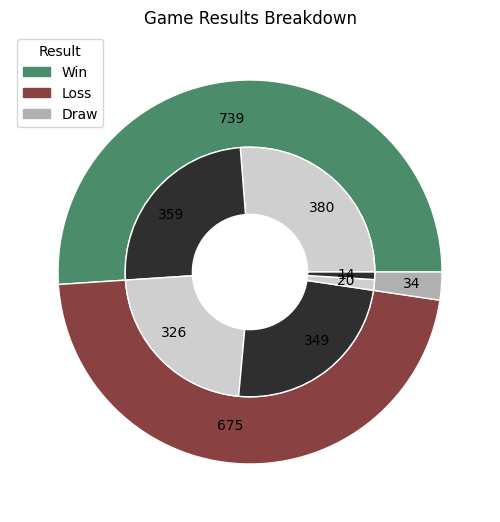

In [8]:
from src.chess_statistics import plot_game_results

games_df = games_df[games_df["rated"] == True]
fig = plot_game_results(games_df, "blitz")

In [9]:
print(games_df["raw_result"].value_counts())

raw_result
win                   1199
timeout                420
resigned               310
checkmated             272
repetition              22
insufficient            10
stalemate                7
agreed                   6
timevsinsufficient       4
abandoned                1
Name: count, dtype: int64


### `chi_square_analysis`

This function performs a statistical test to determine whether there is an association between game outcome and the color played (White or Black).

It uses the **Chi-square test of independence**, along with an effect size measure (Cramer's V), to quantify both statistical significance and practical relevance.

---

#### Inputs

| Parameter | Description                                                                                                       |
| --------- | ----------------------------------------------------------------------------------------------------------------- |
| games_df  | Game-level dataset containing results and player color.                                                           |
| type      | Optional filter for time control (e.g. `"blitz"`, `"rapid"`). If provided, analysis is restricted to that subset. |
| alpha     | Significance threshold for the statistical test (default = 0.05).                                                 |
| plot      | If `True`, displays a heatmap of standardized residuals.                                                          |

---

#### Interpretation

- If `p < alpha`: there is a statistically significant association between color and result.
- If `p ≥ alpha`: no evidence of dependence between color and result.

Effect size interpretation:

| Cramer's V | Strength   |
| ---------- | ---------- |
| < 0.1      | Negligible |
| 0.1 – 0.3  | Small      |
| 0.3 – 0.5  | Moderate   |
| > 0.5      | Strong     |

---

#### Visualization

If enabled, the function plots a heatmap of **standardized residuals**:

- Positive values: observed frequency higher than expected
- Negative values: observed frequency lower than expected
- Magnitude indicates strength of deviation

This helps identify which specific outcome–color combinations drive the statistical association.

---

#### Purpose

This analysis is used to:

- Determine whether playing White or Black affects game outcome
- Quantify whether any advantage exists in the dataset
- Identify imbalance patterns in performance
- Provide statistical grounding beyond simple win-rate comparisons

---


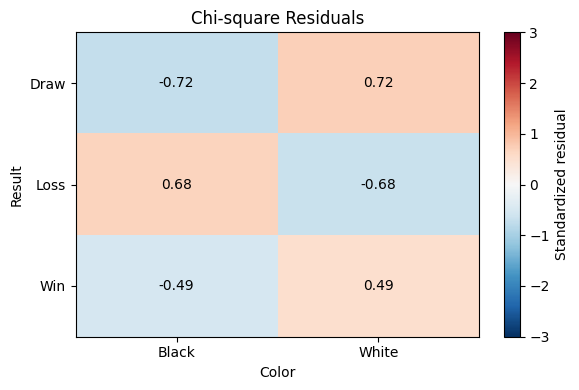

In [10]:
from src.chess_statistics import chi_square_analysis

fig = chi_square_analysis(games_df, type="blitz")

### `accuracy`

This function analyzes the relationship between game outcome, color played, and move quality as measured by Chess.com accuracy.

It computes the average accuracy of played games, conditioned on both the player's color and the game result.

---

#### Inputs

| Parameter | Description                                                                                                       |
| --------- | ----------------------------------------------------------------------------------------------------------------- |
| games_df  | Game-level dataset containing accuracy scores and results.                                                        |
| type      | Optional filter for time control (e.g. `"blitz"`, `"rapid"`). If provided, analysis is restricted to that subset. |

---

#### Output Visualization

The function produces a heatmap where:

- Rows correspond to the side played (White / Black)
- Columns correspond to game result (Win / Loss / Draw)
- Cell values represent **average accuracy**

Each value represents the average quality of play for that category.

---

#### Interpretation

This visualization helps answer:

- Do I play more accurately when I win?
- Is there a systematic difference in accuracy between White and Black?
- Does higher accuracy correlate with better results?
- Are losses associated with low-quality play or simply bad positions?

---


In [11]:
from src.chess_statistics import time_period_analysis

time_period_analysis(games_df)

{'winrate':   time_period  win_rate  games
 0   Afternoon      55.6    545
 1     Evening      56.4    605
 2     Morning      46.9    147
 3       Night      50.9    954}

### `daytime`

This function analyzes how game outcomes vary depending on the time of day the games were played.

It aggregates games by hour and result, and visualizes temporal patterns in performance.

---

#### Inputs

| Parameter | Description                                                                                                       |
| --------- | ----------------------------------------------------------------------------------------------------------------- |
| games_df  | Game-level dataset containing timestamps and results.                                                             |
| type      | Optional filter for time control (e.g. `"blitz"`, `"rapid"`). If provided, analysis is restricted to that subset. |

---

#### Output Visualization

The function produces a line plot where:

- X-axis: hour of the day (0–23)
- Y-axis: number of games played
- Lines: separated by game result

Each line shows how often each outcome occurs at different times of day.

---

#### Interpretation

This visualization helps identify:

- When most games are played during the day
- Whether performance varies with time of day
- Potential fatigue or focus effects (e.g., more losses at night)
- Behavioral patterns in playing schedule

---


<Axes: title={'center': 'Games by Hour and Result'}, xlabel='hour', ylabel='Number of Games'>

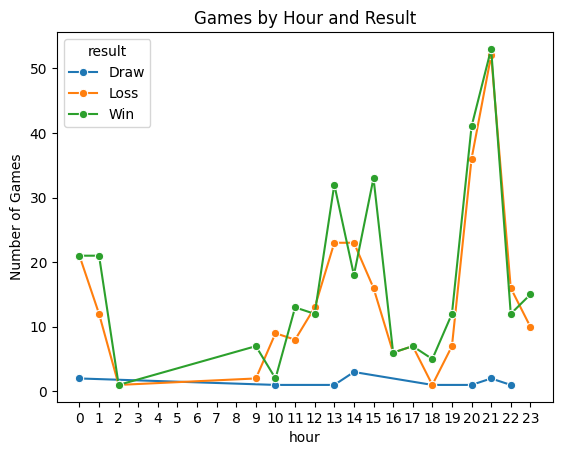

In [12]:
from src.chess_statistics import daytime

daytime(games_df, "bullet")

### `blunders`

This function visualizes blunders by comparing engine evaluation before and after a move.

It focuses only on moves classified as **your mistakes**, and highlights how much the position deteriorated as a result of those moves.

---

#### Inputs

| Parameter | Description                                                                  |
| --------- | ---------------------------------------------------------------------------- |
| result_df | Move-level dataset containing engine evaluations and blunder classification. |

---

#### Visualization Logic

The plot compares:

- `eval_before`: engine evaluation before the move
- `eval_after`: engine evaluation after the move

Each point represents a single blunder.

---

#### Plot Components

- **Scatter points (red)**: individual blunder positions
- **Identity line (y = x)**: no change in evaluation
- **Threshold bands (y = x ± MISTAKE_LL)**:
  - Define the region of acceptable evaluation noise vs actual mistake severity
- **Axes limits**:
  - Fixed to [-1000, 1000] centipawns for interpretability
- **Reference axes**:
  - Horizontal line at y = 0
  - Vertical line at x = 0

---

#### Interpretation

This plot helps to understand:

- How severe your blunders are in engine terms
- Whether mistakes are small inaccuracies or major tactical collapses
- Whether errors tend to occur from already good or already bad positions
- The distribution of evaluation swings caused by mistakes

Each point answers:

> “Given this position, how badly did I worsen it with my move?”

The distance from the identity line corresponds to the magnitude of the mistake.

---


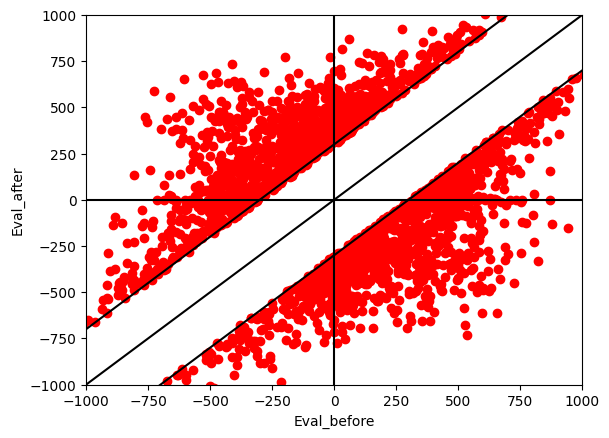

In [13]:
from src.chess_statistics import blunders

blunders(result_df)

### `first_blunder_by_opening`

This function analyzes how early first mistakes occur across different openings.

It links engine-detected blunders with opening categories to study whether certain openings lead to earlier tactical or strategic errors.

---

#### Inputs

| Parameter | Description                                                               |
| --------- | ------------------------------------------------------------------------- |
| result_df | Move-level dataset containing engine analysis and blunder classification. |
| games_df  | Game-level dataset containing metadata such as openings and results.      |

---

#### Methodology

For each opening, the function computes:

| Metric            | Meaning                                         |
| ----------------- | ----------------------------------------------- |
| games             | Total number of games in that opening           |
| blunder_games     | Number of games containing at least one blunder |
| avg_first_blunder | Average move number of first blunder            |
| no_blunder_pct    | Percentage of games without any blunders        |

---

### Filtering

Only openings with more than 5 games are kept to ensure statistical reliability.

---

### Output table

The function prints a ranked summary:

- Openings sorted by **average first blunder move**

This highlights openings where mistakes tend to happen earlier or later.

---

### Visualization

A boxplot is generated:

- X-axis: move number of first blunder
- Y-axis: opening (`simple_opening`)

Each box shows:

- Median first blunder timing
- Spread of error occurrence
- Outliers (very early or very late blunders)

---

### Interpretation

This analysis helps answer:

- Do some openings lead to earlier mistakes?
- Are certain openings more “forgiving”?
- Do complex openings increase tactical errors?
- How stable is my play in different opening systems?

---


               simple_opening  games  blunder_games  avg_first_blunder  \
52                Scotch Game      7              4          27.500000   
13              Dutch Defense     13             10          24.600000   
27      King's Indian Defense     84             60          24.000000   
17          Four Knights Game      9              6          22.666667   
53          Semi-Slav Defense     12              8          22.625000   
29              London System     18             12          22.583333   
3              Benoni Defense      9              5          22.400000   
24          King's Fianchetto     12             11          21.818182   
48               Reti Opening     15              9          21.777778   
36         Old Benoni Defense     24             20          21.550000   
35  Nimzowitsch-Larsen Attack     11             11          21.090909   
7           Caro-Kann Defense    148            103          20.708738   
44    Queen's Gambit Declined    435  

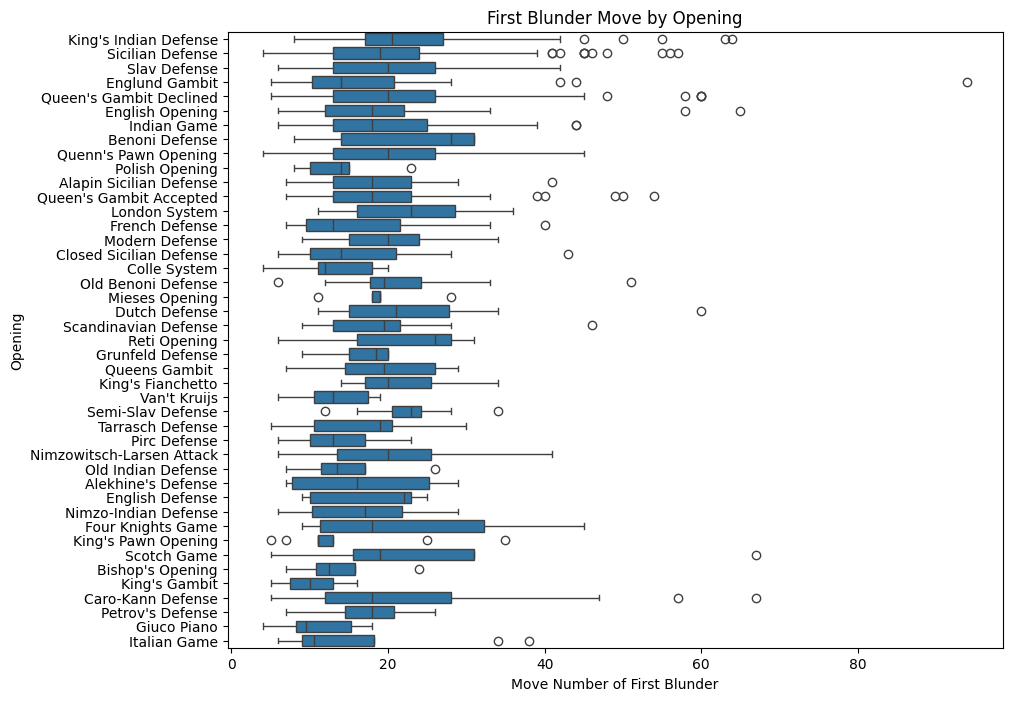

In [14]:
from src.chess_statistics import first_blunder_by_opening

first_blunder_by_opening(result_df, games_df)

### `plot_game`

This function visualizes the evolution of engine evaluation throughout a single chess game.

It provides a move-by-move view of how the position changed, allowing identification of critical turning points, advantages, and decisive mistakes.

---

#### Inputs

| Parameter | Description                                                         |
| --------- | ------------------------------------------------------------------- |
| result_df | Move-level dataset containing engine evaluations and move indices.  |
| link_id   | Unique identifier of the game (corresponding to Chess.com game ID). |

---

#### Plot structure

- X-axis: move number
- Y-axis: engine evaluation
- Background shading emphasizes advantage vs disadvantage phases

---

### Interpretation

This visualization allows you to:

- Identify turning points in the game
- See when advantage shifts occurred
- Understand how mistakes impacted the evaluation
- Visually inspect winning vs losing trajectories
- Relate blunders to game outcome dynamics

---


In [15]:
games_df.head()

,uuid,link_id,link,time_class,time_control,rated,white,white_rating,black,black_rating,...,simple_opening,eco_code,my_color,result,raw_result,white_accuracy,black_accuracy,Time,end_time,moves
0,16e600e5-6668-11f1-88e6-aebfe201000f,170090456418,https://www.chess.com/game/live/170090456418,blitz,180+2,True,ParpasP,1119,meladak,1116,...,King's Indian Defense,/www.chess.com/openings/Kings-Indian-Defense-N...,White,Win,win,76.30,77.90,2026-06-12 16:15:30+02:00,1781273730,d4|g6|c4|Bg7|Nc3|d6|e4|Nf6|h3|O-O|Nf3|Nbd7|Bd3...
1,cd802251-6666-11f1-a4a0-df540901000f,170090036116,https://www.chess.com/game/live/170090036116,blitz,180+2,True,Femcme,1147,ParpasP,1111,...,Sicilian Defense,/www.chess.com/openings/Sicilian-Defense-Open-...,Black,Loss,timeout,71.45,65.14,2026-06-12 16:06:46+02:00,1781273206,e4|c5|Nf3|Nc6|d4|cxd4|Nxd4|e5|Nb5|Nf6|Bg5|Be7|...
2,d719861a-6665-11f1-a4a0-df540901000f,170089724238,https://www.chess.com/game/live/170089724238,blitz,180+2,True,Sherv1,1132,ParpasP,1119,...,Slav Defense,/www.chess.com/openings/Slav-Defense-Modern-Ex...,Black,Loss,timeout,NaN,NaN,2026-06-12 15:58:31+02:00,1781272711,d4|d5|c4|c6|cxd5|cxd5|Nc3|Nf6|Nf3|Nc6|Bg5|e6|a...
3,a1047564-6665-11f1-a536-c0b69601000f,170089655612,https://www.chess.com/game/live/170089655612,blitz,180+2,True,ParpasP,1127,EndgameRookMaster,1159,...,Englund Gambit,/www.chess.com/openings/Englund-Gambit-2.dxe5-...,White,Win,win,90.75,79.94,2026-06-12 15:51:00+02:00,1781272260,d4|e5|dxe5|Nc6|Nf3|Qe7|Bf4|Qb4+|Bd2|Qxb2|Nc3|N...
4,e0f9dce9-6664-11f1-88e6-aebfe201000f,170089414082,https://www.chess.com/game/live/170089414082,blitz,180+2,True,IgorLukashevich,1147,ParpasP,1118,...,Sicilian Defense,/www.chess.com/openings/Sicilian-Defense-Frenc...,Black,Loss,checkmated,87.03,68.49,2026-06-12 15:49:27+02:00,1781272167,e4|c5|Nf3|e6|d4|cxd4|Qxd4|Nc6|Qd1|Nf6|e5|Nxe5|...


You played as white


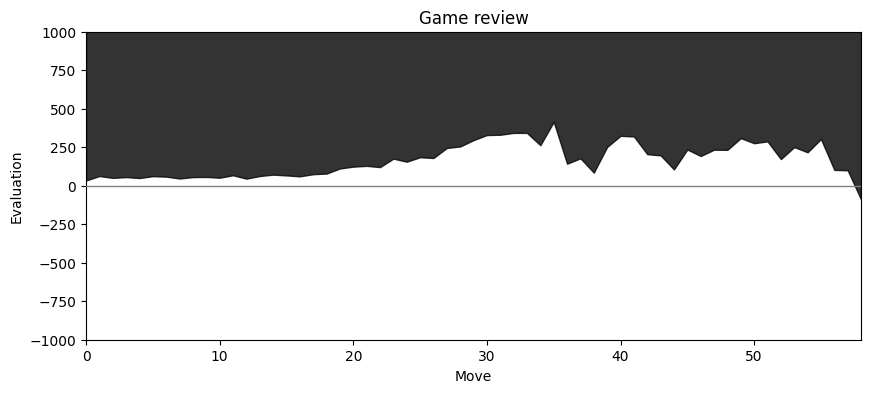

In [16]:
from src.functions import plot_game

plot_game(result_df, link_id="170090456418")

## Personalized Chess Puzzle System

This module converts your real game mistakes into interactive training puzzles.

Unlike standard tactical puzzles, these are extracted directly from your own games and therefore target your specific weaknesses.

The system includes:

- Puzzle generation from blunders
- Position reconstruction
- Engine-based evaluation
- Interactive solving interface

---

## 1. `generate_chess_puzzles`

This function extracts structured puzzle positions from analyzed games.

---

### Core Idea

Each puzzle is built from a **blunder context**:

- The position immediately before a critical mistake
- The opponent’s last move
- Your incorrect response (or missed tactic)

This allows reconstruction of _real decision points_.

---

#### Puzzle construction

Each puzzle stores:

| Field       | Meaning                       |
| ----------- | ----------------------------- |
| uuid        | Game identifier               |
| link_id     | External game reference       |
| type        | Blunder type (my/opponent)    |
| my_color    | Side played                   |
| fen         | Position before mistake       |
| move_before | Opponent’s last move (UCI)    |
| move_curr   | My blunder move (UCI)         |
| played_move | My move in SAN                |
| eval_before | Engine evaluation before move |
| eval_after  | Engine evaluation after move  |

---

### Output

A structured DataFrame of personalized training puzzles.

---

## 2. `render_puzzle`

This function renders an interactive chess puzzle in a Jupyter environment.

---

### Features

Each puzzle includes:

- Interactive chess board
- Highlighted key squares
- Arrow showing the played move
- Evaluation bars (position quality)
- Input box for user solution
- Engine feedback after submission

---

### Visualization

The board displays:

- **Highlighted squares**: key tactical positions
- **Red arrow**: move actually played
- **Orientation adjusted** to player's perspective

---

### Puzzle Types

#### My blunder

- You made a mistake in the game
- Goal: find a better move than the one played

#### Opponent blunder

- Opponent made a mistake
- Goal: exploit the tactical opportunity

---

### Engine Analysis

For each puzzle:

- Stockfish evaluates:
  - Best move from the position
  - User-provided move
- Computes:
  - Loss vs best move (centipawns)
  - Improvement over played move

---

### Feedback system

After submitting a move, the system provides:

- Best move comparison
- Evaluation loss in centipawns
- Quality classification:
  - Excellent
  - Similar
  - Worse
  - Improvement but suboptimal

---

## 3. `run_puzzle_viewer`

This function launches the interactive puzzle trainer.

---

### Features

- Slider-based navigation through puzzles
- Dynamic rendering of each position
- Immediate update of puzzle board and evaluation

---

### Purpose

This module transforms passive game analysis into an **active learning loop**:

> Instead of only detecting mistakes, the system converts them into targeted training material.


In [ ]:
from src.puzzle import run_puzzle_viewer

# run_puzzle_viewer(result_df)

IntSlider(value=0, continuous_update=False, description='Puzzle:', max=3640)

Output()

In [18]:
games_df

,uuid,link_id,link,time_class,time_control,rated,white,white_rating,black,black_rating,...,simple_opening,eco_code,my_color,result,raw_result,white_accuracy,black_accuracy,Time,end_time,moves
0,16e600e5-6668-11f1-88e6-aebfe201000f,170090456418,https://www.chess.com/game/live/170090456418,blitz,180+2,True,ParpasP,1119,meladak,1116,...,King's Indian Defense,/www.chess.com/openings/Kings-Indian-Defense-N...,White,Win,win,76.30,77.90,2026-06-12 16:15:30+02:00,1781273730,d4|g6|c4|Bg7|Nc3|d6|e4|Nf6|h3|O-O|Nf3|Nbd7|Bd3...
1,cd802251-6666-11f1-a4a0-df540901000f,170090036116,https://www.chess.com/game/live/170090036116,blitz,180+2,True,Femcme,1147,ParpasP,1111,...,Sicilian Defense,/www.chess.com/openings/Sicilian-Defense-Open-...,Black,Loss,timeout,71.45,65.14,2026-06-12 16:06:46+02:00,1781273206,e4|c5|Nf3|Nc6|d4|cxd4|Nxd4|e5|Nb5|Nf6|Bg5|Be7|...
2,d719861a-6665-11f1-a4a0-df540901000f,170089724238,https://www.chess.com/game/live/170089724238,blitz,180+2,True,Sherv1,1132,ParpasP,1119,...,Slav Defense,/www.chess.com/openings/Slav-Defense-Modern-Ex...,Black,Loss,timeout,NaN,NaN,2026-06-12 15:58:31+02:00,1781272711,d4|d5|c4|c6|cxd5|cxd5|Nc3|Nf6|Nf3|Nc6|Bg5|e6|a...
3,a1047564-6665-11f1-a536-c0b69601000f,170089655612,https://www.chess.com/game/live/170089655612,blitz,180+2,True,ParpasP,1127,EndgameRookMaster,1159,...,Englund Gambit,/www.chess.com/openings/Englund-Gambit-2.dxe5-...,White,Win,win,90.75,79.94,2026-06-12 15:51:00+02:00,1781272260,d4|e5|dxe5|Nc6|Nf3|Qe7|Bf4|Qb4+|Bd2|Qxb2|Nc3|N...
4,e0f9dce9-6664-11f1-88e6-aebfe201000f,170089414082,https://www.chess.com/game/live/170089414082,blitz,180+2,True,IgorLukashevich,1147,ParpasP,1118,...,Sicilian Defense,/www.chess.com/openings/Sicilian-Defense-Frenc...,Black,Loss,checkmated,87.03,68.49,2026-06-12 15:49:27+02:00,1781272167,e4|c5|Nf3|e6|d4|cxd4|Qxd4|Nc6|Qd1|Nf6|e5|Nxe5|...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2421,4eb450cf-bc9a-11ef-8893-df8f3801000f,121529953114,https://www.chess.com/game/live/121529953114,rapid,600,True,ParpasP,271,Ahmet53598,463,...,French Defense,/www.chess.com/openings/French-Defense-Kings-I...,White,Loss,timeout,NaN,NaN,2024-12-17 18:29:39+01:00,1734456579,e4|e6|d3|d5|e5|Bb4+|c3|f6|cxb4|fxe5|Nf3|e4|Bg5...
2422,874dac52-bc98-11ef-aa66-6dda8e01000f,121529692026,https://www.chess.com/game/live/121529692026,blitz,180+2,True,Andrewdobtplaywithme,318,ParpasP,438,...,King's Pawn Opening,/www.chess.com/openings/Kings-Pawn-Opening-1...e5,Black,Win,win,62.02,69.30,2024-12-17 18:08:38+01:00,1734455318,e4|e5|f3|Qh4+|g3|Qe7|f4|exf4|gxf4|Qxe4+|Qe2|Qx...
2423,5b88d5e0-ac2b-11ef-a187-ae657801000f,121117490854,https://www.chess.com/game/live/121117490854,blitz,180+2,True,ParpasP,370,miphtahusseyn,551,...,Pirc Defense,/www.chess.com/openings/Pirc-Defense-Main-Line...,White,Loss,timeout,NaN,NaN,2024-11-26 20:25:32+01:00,1732649132,d4|Nf6|Nc3|g6|e4|d6|f3|Bg7|Be3|O-O|Bd3|Nc6|Nge...
2424,15c46c40-ac2b-11ef-997c-4978a401000f,121117458476,https://www.chess.com/game/live/121117458476,blitz,180+2,True,miphtahusseyn,545,ParpasP,432,...,Italian Game,/www.chess.com/openings/Italian-Game-Knight-At...,Black,Loss,resigned,NaN,NaN,2024-11-26 20:19:14+01:00,1732648754,e4|e5|Nf3|Nc6|Bc4|Nf6|Ng5|d5|exd5|Nxd5|Nxf7|Kx...


In [31]:
result_df

,link_id,uuid,move_index,move_no,player,move,clock_before,clock_after,thinking_time,my_move,eval_before,eval_after,delta,blunder,blunder_type,move_type,fen,end_time
12105,170090456418,16e600e5-6668-11f1-88e6-aebfe201000f,0,1,white,d4,180.0,181.3,0.7,True,0,34,34,0,no_blunder,Best,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1781273730
12106,170090456418,16e600e5-6668-11f1-88e6-aebfe201000f,1,1,black,g6,180.0,180.1,1.9,False,34,63,-29,0,no_blunder,Excellent,rnbqkbnr/pppppp1p/6p1/8/3P4/8/PPP1PPPP/RNBQKBN...,1781273730
12107,170090456418,16e600e5-6668-11f1-88e6-aebfe201000f,2,2,white,c4,181.3,182.9,0.4,True,63,51,-12,0,no_blunder,Excellent,rnbqkbnr/pppppp1p/6p1/8/2PP4/8/PP2PPPP/RNBQKBN...,1781273730
12108,170090456418,16e600e5-6668-11f1-88e6-aebfe201000f,3,2,black,Bg7,180.1,180.1,2.0,False,51,56,-5,0,no_blunder,Best,rnbqk1nr/ppppppbp/6p1/8/2PP4/8/PP2PPPP/RNBQKBN...,1781273730
12109,170090456418,16e600e5-6668-11f1-88e6-aebfe201000f,4,3,white,Nc3,182.9,184.6,0.3,True,56,50,-6,0,no_blunder,Best,rnbqk1nr/ppppppbp/6p1/8/2PP4/2N5/PP2PPPP/R1BQK...,1781273730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128356,121117316976,e71d2c48-ac29-11ef-92d2-02107401000f,36,19,white,Rf8+,28.3,26.2,4.1,True,-213,-297,-84,0,no_blunder,Inaccuracy,r1bk1R2/ppp4p/3p4/8/8/b2P4/P1Pn2PP/4R2K b - - ...,1732648585
128357,121117316976,e71d2c48-ac29-11ef-92d2-02107401000f,37,19,black,Kd7,9.4,7.0,4.4,False,-297,-261,-36,0,no_blunder,Good,r1b2R2/pppk3p/3p4/8/8/b2P4/P1Pn2PP/4R2K w - - ...,1732648585
128358,121117316976,e71d2c48-ac29-11ef-92d2-02107401000f,38,20,white,Rf2,26.2,21.4,6.8,True,-261,-368,-107,0,no_blunder,Mistake,r1b5/pppk3p/3p4/8/8/b2P4/P1Pn1RPP/4R2K b - - 3 20,1732648585
128359,121117316976,e71d2c48-ac29-11ef-92d2-02107401000f,39,20,black,Bb4,7.0,2.8,6.2,False,-368,-317,-51,0,no_blunder,Inaccuracy,r1b5/pppk3p/3p4/8/1b6/3P4/P1Pn1RPP/4R2K w - - ...,1732648585


In [35]:
from src.puzzle import generate_chess_puzzles

puzzles_df = generate_chess_puzzles(result_df)

In [36]:
puzzles_df

,uuid,link_id,type,my_color,fen,move_before,move_curr,played_move,eval_before,eval_after,clock_before,clock_after,thinking_time
0,00795940-2240-11f1-ba3a-0480d301000f,166081612344,my_blunder,white,8/8/1p6/p1p2Kp1/2Pp4/P5P1/7k/3B4 w - - 0 48,g2h2,f5g5,Kxg5,415,49,3.4,3.8,0.6
1,00aaacdf-8656-11f0-8385-93dc4f01000f,142551833498,opponent_blunder,black,rnbqkb1r/pB3ppp/5n2/2p5/8/5Q2/PPPP1PPP/RNB1K1N...,d5b7,c8b7,Bxb7,-404,189,183.8,180.2,5.6
2,00aaacdf-8656-11f0-8385-93dc4f01000f,142551833498,my_blunder,black,1r4k1/5pp1/6qp/2pnB3/7Q/7P/PP3PP1/4R1K1 b - - ...,c3e5,d5b4,Nb4,167,553,15.4,11.0,6.4
3,00b70112-b68e-11f0-b95c-44fdaf01000f,144965062652,opponent_blunder,white,QR6/7p/5p2/5kp1/8/5P1P/5K2/8 w - - 1 40,g6f5,a8a7,Qa7,10000,864,0.7,0.5,0.2
4,00de250f-d399-11ef-a106-d377a001000f,122172444578,my_blunder,black,r1bq3r/ppp2kpp/2n5/2bBp3/4P3/8/PPPP1PPP/R1BQK2...,c4d5,f7e7,Ke7,-187,235,126.2,120.0,8.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3306,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,my_blunder,black,r1b1k2r/pp3p1p/4pp2/3p4/1P4R1/P4P2/2P2P1q/R2QK...,g1g4,e6e5,e5,-346,24,154.5,123.1,36.4
3307,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,my_blunder,black,2r1k2r/p1P2pRp/4b3/1B1p1p2/5q2/P4p2/5P2/2RQK3 ...,f1b5,e6d7,Bd7,-345,222,32.1,26.1,11.0
3308,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,my_blunder,black,2r1k2r/p1PB1pRp/8/3p1p2/5q2/P4p2/5P2/2RQK3 b k...,b5d7,e8d7,Kxd7,246,10000,26.1,29.9,1.2
3309,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,opponent_blunder,black,2r1k2r/p1PR3p/8/3p1p2/5q2/P4p2/5P2/2RQK3 b - -...,f7d7,e8d7,Kxd7,-579,-232,32.5,36.3,1.2


In [22]:
moves_df

,uuid,link_id,time_class,time_control,move_no,move_index,turn,move,eval_before,eval_after,clock,clock_sec,my_move,fen,end_time,depth
0,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,1,0,white,d4,0.0,29,0:03:01.1,181.1,True,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,1747914235,10
1,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,1,1,black,Nf6,29.0,30,0:03:00,180.0,False,rnbqkb1r/pppppppp/5n2/8/3P4/8/PPP1PPPP/RNBQKBN...,1747914235,10
2,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,2,2,white,c4,30.0,37,0:03:02.5,182.5,True,rnbqkb1r/pppppppp/5n2/8/2PP4/8/PP2PPPP/RNBQKBN...,1747914235,10
3,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,2,3,black,e6,37.0,37,0:03:01.1,181.1,False,rnbqkb1r/pppp1ppp/4pn2/8/2PP4/8/PP2PPPP/RNBQKB...,1747914235,10
4,0039856a-3701-11f0-830d-ba100d01000f,138735449314,blitz,180+2,3,4,white,Nc3,37.0,37,0:03:03.6,183.6,True,rnbqkb1r/pppp1ppp/4pn2/8/2PP4/2N5/PP2PPPP/R1BQ...,1747914235,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151074,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,31,60,white,Qe6+,-271.0,-262,0:00:12.9,12.9,False,2k4r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/2R2K2 b - - 2 31,1744061663,10
151075,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,31,61,black,Kd8,-262.0,10000,0:00:37.1,37.1,True,3k3r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/2R2K2 w - - 3 32,1744061663,10
151076,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,32,62,white,Rd1+,10000.0,10000,0:00:10.7,10.7,False,3k3r/p1r4p/4Q3/5p2/5q2/P4p2/5P2/3R1K2 b - - 4 32,1744061663,10
151077,ffe072d3-13f5-11f0-a0dd-ce543c01000f,137137795536,blitz,300+5,32,63,black,Rd7,10000.0,10000,0:00:33.9,33.9,True,3k3r/p2r3p/4Q3/5p2/5q2/P4p2/5P2/3R1K2 w - - 5 33,1744061663,10


In [23]:
moves_df["move_no"]

0          1
1          1
2          2
3          2
4          3
          ..
151074    31
151075    31
151076    32
151077    32
151078    33
Name: move_no, Length: 151079, dtype: int64

In [29]:
try:
    a = "180".split("+")[1]
except:
    a = 0
print(a)

0


In [104]:
import chess

board = chess.Board()
board.set_fen("1R6/Q6p/5p2/5kp1/8/5P1P/5K2/8 b - - 2 40")

In [105]:
from config import STOCKFISH_PATH

engine = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_PATH))

In [106]:
from src.cache import evaluate

evaluate(board, engine, 40)

10000